# 文本分类实例

## Step1 导入相关包


In [1]:
from transformers import AutoTokenizer,AutoModelForSequenceClassification

c:\Users\Aaron\AppData\Local\Programs\miniconda3\envs\Bert\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step2 加载数据

In [2]:
import pandas as pd

data = pd.read_csv("./data/ChnSentiCorp_htl_all.csv")
data.head()

,label,review
0,1,"距离川沙公路较近,但是公交指示不对,如果是""蔡陆线""的话,会非常麻烦.建议用别的路线.房间较..."
1,1,商务大床房，房间很大，床有2M宽，整体感觉经济实惠不错!
2,1,早餐太差，无论去多少人，那边也不加食品的。酒店应该重视一下这个问题了。房间本身很好。
3,1,宾馆在小街道上，不大好找，但还好北京热心同胞很多~宾馆设施跟介绍的差不多，房间很小，确实挺小...
4,1,"CBD中心,周围没什么店铺,说5星有点勉强.不知道为什么卫生间没有电吹风"


In [3]:
data = data.dropna()
data

,label,review
0,1,"距离川沙公路较近,但是公交指示不对,如果是""蔡陆线""的话,会非常麻烦.建议用别的路线.房间较..."
1,1,商务大床房，房间很大，床有2M宽，整体感觉经济实惠不错!
2,1,早餐太差，无论去多少人，那边也不加食品的。酒店应该重视一下这个问题了。房间本身很好。
3,1,宾馆在小街道上，不大好找，但还好北京热心同胞很多~宾馆设施跟介绍的差不多，房间很小，确实挺小...
4,1,"CBD中心,周围没什么店铺,说5星有点勉强.不知道为什么卫生间没有电吹风"
...,...,...
7761,0,尼斯酒店的几大特点：噪音大、环境差、配置低、服务效率低。如：1、隔壁歌厅的声音闹至午夜3点许...
7762,0,盐城来了很多次，第一次住盐阜宾馆，我的确很失望整个墙壁黑咕隆咚的，好像被烟熏过一样家具非常的...
7763,0,看照片觉得还挺不错的，又是4星级的，但入住以后除了后悔没有别的，房间挺大但空空的，早餐是有但...
7764,0,我们去盐城的时候那里的最低气温只有4度，晚上冷得要死，居然还不开空调，投诉到酒店客房部，得到...


## Step3 创建Dataset

In [4]:
from torch.utils.data import Dataset

class MyDataset(Dataset):

    def __init__(self) -> None:
        super().__init__()
        self.data = pd.read_csv("./data/ChnSentiCorp_htl_all.csv")
        self.data = self.data.dropna()
    
    def __getitem__(self, index):
        return self.data.iloc[index]["review"],self.data.iloc[index]["label"]
    
    def __len__(self):
        return len(self.data)

In [5]:
dataset = MyDataset()
for i in range(5):
    print(dataset[i])

('距离川沙公路较近,但是公交指示不对,如果是"蔡陆线"的话,会非常麻烦.建议用别的路线.房间较为简单.', np.int64(1))
('商务大床房，房间很大，床有2M宽，整体感觉经济实惠不错!', np.int64(1))
('早餐太差，无论去多少人，那边也不加食品的。酒店应该重视一下这个问题了。房间本身很好。', np.int64(1))
('宾馆在小街道上，不大好找，但还好北京热心同胞很多~宾馆设施跟介绍的差不多，房间很小，确实挺小，但加上低价位因素，还是无超所值的；环境不错，就在小胡同内，安静整洁，暖气好足-_-||。。。呵还有一大优势就是从宾馆出发，步行不到十分钟就可以到梅兰芳故居等等，京味小胡同，北海距离好近呢。总之，不错。推荐给节约消费的自助游朋友~比较划算，附近特色小吃很多~', np.int64(1))
('CBD中心,周围没什么店铺,说5星有点勉强.不知道为什么卫生间没有电吹风', np.int64(1))


## Step4 划分数据集

In [6]:
import torch
from torch.utils.data import random_split

# 三划分
train_len = int(0.8 * len(dataset))
valid_len = int(0.1 * len(dataset))
test_len = len(dataset) - train_len - valid_len

trainset, validset, testset = random_split(
    dataset,
    [train_len, valid_len, test_len],
    generator=torch.Generator().manual_seed(42)
)
len(trainset),len(validset),len(testset)

(6212, 776, 777)

In [7]:
for i in range(10):
    print(trainset[i])

('房间很好，符合五星级的标准。酒店离沟口及边边街都比较近，是去九寨沟旅游的最佳选择。补充点评2008年7月21日：地震对该酒店没有任何影响。宾馆反馈2008年7月24日：谢谢您的点评,欢迎下次下榻我酒店!我们将为您提供更周到的服务及优质的产品.', np.int64(1))
('性价比还不错。。。算是当地最好的酒店了如果是第一次去的话，可能会发现不太好找', np.int64(1))
('打开评价页面就很不一样，很少有酒店能这么认真的作评价回复，这一点就很不错了。我们是A9上海至湖州通车那天来湖州逛逛的，定了太湖豪华房，应该算是不错，建筑比较吸引人，不过那天风大雨大就一直在房间里，可能观念的问题吧，就五星标准来说，房间足够大，浴室也做的很漂亮，但却少许多东西，感觉空落落的，床上用品也只有简单的两个枕头、一条薄被，看上去就好冷啊~应该会比较适合夏季度假吧：）由于临时有事，没有过夜就提前退房了，前台mm还很遗憾的说，下次一定要来住哦，听了蛮窝心的，我想应该会在暖和些的日子再来的：）也希望再次入住前酒店能做更好的改进，哈哈补充点评2008年1月17日：关键没有国际卫视，这一点作为五星标准比较令人不能接受：S', np.int64(1))
('5月14日入住了这家酒店，服务确实很好，前台会亲自带领客人到房间，并介绍房间设施，得知我自带电脑，立刻把网线从房间内电脑上拆下，放在桌旁待用。晚上六点后会送果盘和小礼物，那天是香蕉和小西红柿，两个毛绒公仔。房间相较其他济南同价位的酒店显得新，很干净，位置也很好！推荐！', np.int64(1))
('位置是非常好，就在省政府对面，离步行街也很近，但房间内的条件太一般，达不到四星。我住的是398元的，还没包早餐，最多也就值200元，不过酒店能到机场接客确实很不错。如果住一晚也值了，如果住三晚以上，还是选择别的实惠一点的酒店吧。现在我才发现，通过携程网订房价格很没优势的，都是提高了价格后再折扣，折后价格比不上其他的普通酒店，以后还是要自己直接跟别的酒店联系，省了中间环节，价格会低很多，并且条件还会更好。', np.int64(1))
('1、我原本是通过丽江某旅行社订房在香格里拉大道某酒店，到达酒店后，对酒店不甚满意。出租车司机向我推荐了古城里的“丽王酒店”、“王府饭店”、“和玺酒店”。对比三家酒店，和玺酒店更具有古朴特色，一个个院落

## Step5 创建Dataloader

In [8]:
import torch

tokenizer = AutoTokenizer.from_pretrained("hfl/rbt3")

def collate_func(batch):
    texts,labels = [],[]
    for item in batch:
        texts.append(item[0])
        labels.append(item[1])
    inputs = tokenizer(texts,max_length=128,padding="max_length",truncation=True,return_tensors="pt", dtype=torch.long)
    inputs["labels"] = torch.tensor(labels)
    return inputs

In [9]:
from torch.utils.data import DataLoader

trainloader = DataLoader(trainset,batch_size=64,shuffle=True,collate_fn=collate_func)
validloader = DataLoader(validset,batch_size=128,shuffle=False,collate_fn=collate_func)
testloader = DataLoader(testset,batch_size=128,shuffle=False,collate_fn=collate_func)

In [10]:
next(enumerate(trainloader))

(0,
 {'input_ids': tensor([[ 101, 1372, 5543,  ...,    0,    0,    0],
         [ 101,  711, 2145,  ...,    0,    0,    0],
         [ 101,  855, 5390,  ...,    0,    0,    0],
         ...,
         [ 101, 3517, 3461,  ...,    0,    0,    0],
         [ 101, 6821,  702,  ...,    0,    0,    0],
         [ 101, 6230, 2533,  ..., 8026, 8026,  102]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 1, 1, 1]]), 'labels': tensor([0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
         0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 

## Step6 创建模型及优化器

In [11]:
import torch.nn as nn
from transformers import AutoModel


class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained("hfl/rbt3")
        
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(768, 2)    
        # 改进分类头（MLP）
        # self.classifier = nn.Sequential(
        #     nn.Linear(768, 256),
        #     nn.ReLU(),
        #     nn.Dropout(0.1),
        #     nn.Linear(256, 2)
        # )

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)

        last_hidden = outputs.last_hidden_state

        # 把padding位置设成极小值
        mask = attention_mask.unsqueeze(-1).expand(last_hidden.size())
        last_hidden[mask == 0] = -1e9

        max_pool = torch.max(last_hidden, dim=1).values

        # 加入 Dropout: 对池化后的全局特征进行随机失活
        max = self.dropout(max_pool)

        logits = self.classifier(max)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {"loss": loss, "logits": logits}

In [12]:
from torch.optim import Adam


model = MyModel().cuda()
optimizer = Adam(model.parameters(), lr=1e-6)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=21)

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 37333.99it/s]
BertModel LOAD REPORT from: hfl/rbt3
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Step7 训练与验证

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "c:\Users\Aaron\AppData\Local\Programs\miniconda3\envs\Bert\Lib\site-packages\huggingface_hub\utils\_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Aaron\AppData\Local\Programs\miniconda3\envs\Bert\Lib\site-packages\httpx\_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/rbt3/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\Aaron\AppData\Local\Programs\miniconda3\envs\Bert\Lib\threading.py", line 1082, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "

Epoch: 0 | Step: 0 | Loss: 0.8442
文本: 性 价 比 就 算 可 以 ， 但 地 点 有 点 背 ， 很 多 出 租 车 不 太 认 识 ， 又 是 单 行 路 所 以 交 通 不 是 很 方 便 。 但 考 虑 到 价 格 因 素 ， 这 家 店 还 可 以 。 就 是 房 间 带 个 窗 户 是 露 在 走 廊 里 ， 没 窗 帘 隔 音 不 好 。 所 以 私 密 性 不 是 很 好 。
预测: 1
真实: 0
--------------------------------------------------
文本: 以 前 在 这 里 住 过 感 觉 还 不 错 ， 但 是 这 次 很 差 劲 ， 以 后 不 住 在 这 里 了 。 1 、 天 黑 以 后 到 的 宾 馆 ， 出 了 电 梯 以 后 ， 楼 道 黑 黑 的 ， 都 看 不 清 楚 ； 2 、 订 的 豪 华 数 码 间 ， 但 是 进 去 以 后 没 有 找 到 网 线 ， 随 后 打 电 话 问 客 房 服 务 ， 被 告 知 需 要 用 猫 ， 于 是 去 找 。 等 了 大 约 1 个 半 小 时 才 拿 来 第 二 天
预测: 1
真实: 0
--------------------------------------------------
文本: 好 烂 的 酒 店 ， 说 是 宾 馆 ， 感 觉 一 点 不 好 ， 大 堂 在 一 边 像 个 临 时 的 ， 门 口 没 有 任 何 安 保 人 员 ， 窗 户 旁 边 就 是 停 放 自 行 车 的 ， 毫 无 安 全 感 。 酒 店 设 施 陈 旧 ， 床 又 小 又 难 睡 ， 不 提 供 纯 净 水 ， 烧 水 非 常 难 喝 。 卫 生 间 的 条 件 连 好 点 的 招 待 所 都 不 如 。 早 餐 样 式 少 还 难 吃 。 这 是 住 过 得 最 差 的 星 级 酒 店 ，
预测: 1
真实: 0
--------------------------------------------------
文本: 房 间 总 体 来 说 不 错 ， 比 较 干 净 ， 性 价 比 还 可 以 ， 只 是 晚 上 太 晚 回 去 大 门 是 关 的 ， 要 得 叫 人 起 来 开 门 ，

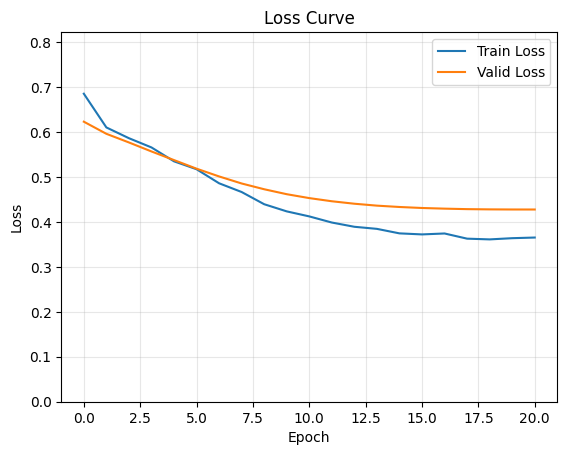

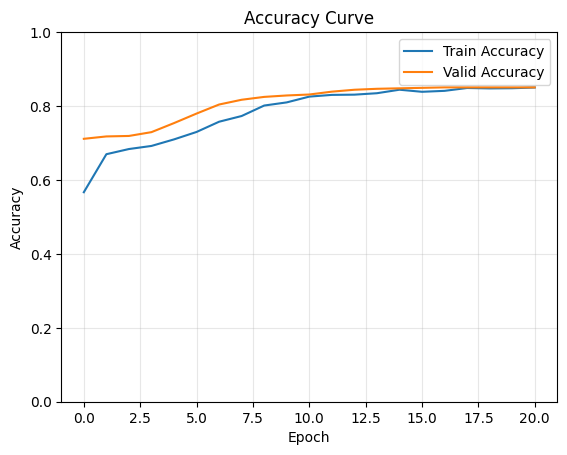

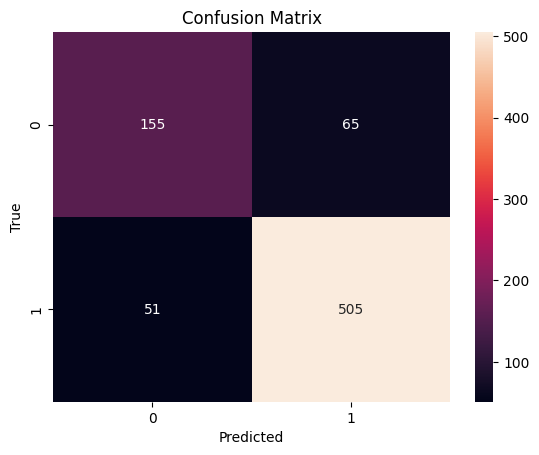

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def evaluate(model, validloader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    preds = []
    labels = []
    wrong_cases = []

    with torch.inference_mode():
        for batch in validloader:
            batch = {k: v.to(device) for k, v in batch.items()}

            output = model(**batch)
            loss = output['loss']
            logits = output['logits']

            total_loss += loss.item()

            pred = torch.argmax(logits, dim=-1)

            preds.extend(pred.cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())

            correct += (pred == batch["labels"]).sum().item()
            total += batch["labels"].size(0)

                        # ===== 错误案例分析 =====
            for i in range(len(pred)):
                if pred[i] != batch["labels"][i]:

                    text = tokenizer.decode(
                        batch["input_ids"][i].cpu(),
                        skip_special_tokens=True
                    )

                    wrong_cases.append({
                        "text": text,
                        "pred": pred[i].item(),
                        "label": batch["labels"][i].item()
                    })

    acc = correct / total
    avg_loss = total_loss / len(validloader)

    return acc, avg_loss, preds, labels, wrong_cases

def train(model, trainloader, validloader, optimizer, scheduler, epochs=3, log_step=100):
    global_step = 0

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    best_acc = 0

    for ep in range(epochs):
        model.train()
        total_loss = 0
        correct_train = 0
        total_train = 0

        for batch in trainloader:
            batch = {k: v.to(device) for k, v in batch.items()}

            optimizer.zero_grad()

            output = model(**batch)
            loss = output['loss']

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # 训练集 Accuracy
            pred = torch.argmax(output['logits'], dim=-1)
            correct_train += (pred == batch["labels"]).sum().item()
            total_train += batch["labels"].size(0)

            if global_step % log_step == 0:
                print(f"Epoch: {ep} | Step: {global_step} | Loss: {loss.item():.4f}")

            global_step += 1

        
        scheduler.step()
        train_acc = correct_train / total_train
        train_loss = total_loss / len(trainloader)

        # 验证
        val_acc, val_loss, preds, labels, wrong_cases = evaluate(model, validloader)
        for case in wrong_cases:
            print("文本:", case["text"])
            print("预测:", case["pred"])
            print("真实:", case["label"])
            print("-"*50)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        valid_losses.append(val_loss)
        valid_accs.append(val_acc)

        print(f"\nEpoch {ep}:")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Acc: {train_acc:.4f}")
        print(f"Valid Loss: {val_loss:.4f}")
        print(f"Valid Acc: {val_acc:.4f}\n")

        # 保存最优模型
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pt")
            print("✅ Best model saved!")

    return train_losses, train_accs, valid_losses, valid_accs, preds, labels, wrong_cases

def plot_curves(train_losses, train_accs, valid_losses, valid_accs):
    epochs = range(len(train_losses))

    # Loss
    plt.figure()
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, valid_losses, label="Valid Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.ylim(0, max(max(train_losses), max(valid_losses)) * 1.2)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(epochs, train_accs, label="Train Accuracy")
    plt.plot(epochs, valid_accs, label="Valid Accuracy")
    plt.legend()
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

train_losses, train_accs, valid_losses, valid_accs, preds, labels, wrong_cases = train(
    model,
    trainloader,
    validloader,
    optimizer,
    scheduler,
    epochs=21
)

plot_curves(train_losses, train_accs, valid_losses, valid_accs)

plot_confusion_matrix(labels, preds)

In [ ]:
import numpy as np


def evaluate():
    model.eval()
    acc_num = 0
    preds, labels = [], []
    with torch.inference_mode():
        for batch in validloader:
            if torch.cuda.is_available():
                batch = {k: v.cuda() for k,v in batch.items()}
            output = model(**batch)
            pred = torch.argmax(output['logits'],dim=-1)
            preds.extend(pred.cpu().tolist())
            labels.extend(batch["labels"].cpu().tolist())
            acc_num += (pred.long() == batch["labels"].long()).float().sum()
    
    print(np.mean(preds), np.mean(labels))
    # print(confusion_matrix(labels, preds))
    return acc_num / len(validset)

def train(epoch=3,log_step=100):
    global_step = 0
    for ep in range(epoch):
        model.train()
        for batch in trainloader:
            if torch.cuda.is_available():
                batch = {k: v.cuda() for k,v in batch.items()}
            optimizer.zero_grad()
            output = model(**batch)
            output['loss'].backward()
            optimizer.step()
            if global_step % log_step == 0:
                print(f"ep: {ep},global_step: {global_step},loss: {output['loss'].item()}")
            global_step += 1
        acc = evaluate()
        print(f"ep : {ep}, acc : {acc}")

In [ ]:
# 不训练，直接evaluate
acc = evaluate()
print("微调前准确率:", acc)

In [ ]:
train()

In [ ]:
# 训练后，再次evaluate
acc = evaluate()
print("微调后准确率:", acc)

In [14]:
import numpy as np


def final_test():
    model.eval()
    acc_num = 0
    preds, labels = [], []
    with torch.inference_mode():
        for batch in testloader:
            if torch.cuda.is_available():
                batch = {k: v.cuda() for k,v in batch.items()}
            output = model(**batch)
            pred = torch.argmax(output['logits'],dim=-1)
            preds.extend(pred.cpu().tolist())
            labels.extend(batch["labels"].cpu().tolist())
            acc_num += (pred.long() == batch["labels"].long()).float().sum()
    
    print(np.mean(preds), np.mean(labels))
    # print(confusion_matrix(labels, preds))
    return acc_num / len(testset)

final_acc = final_test()
print("最终测试集准确率:", final_acc)

0.712998712998713 0.6885456885456885
最终测试集准确率: tensor(0.8649, device='cuda:0')


In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()

In [ ]:
print(model)

In [ ]:
model.save_pretrained("./rbt3_sentiment_model")

## Step9 模型预测

In [ ]:
sen = "我觉得这家酒店不错，饭很好吃"
id2_label = {0 : "差评!",1 :"好评!"}

model.eval()
with torch.inference_mode():
    inputs = tokenizer(sen,return_tensors="pt")
    inputs = {k : v.cuda() for k,v in inputs.items()}
    logits = model(**inputs).logits
    pred = torch.argmax(logits,dim=-1)
    print(f"输入: {sen} \n 模型预测结果: {id2_label.get(pred.item())}")

In [ ]:
import gradio as gr

id2_label = {0: "差评!", 1: "好评!"}

def predict_sentiment(text):
    model.eval()
    with torch.inference_mode():
        inputs = tokenizer(text, return_tensors="pt", max_length=128, padding="max_length", truncation=True)
        inputs = {k: v.cuda() for k, v in inputs.items()}
        logits = model(**inputs).logits
        pred = torch.argmax(logits, dim=-1)
        label = id2_label.get(pred.item())
        confidence = torch.softmax(logits, dim=-1)[0][pred.item()].item()
        return f"{label} (置信度: {confidence:.2f})"

iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="请输入您要分析的酒店评论..."),
    outputs="text",
    title="酒店评论情感分析",
    description="输入一段酒店评论，模型将预测其情感倾向（好评或差评）。"
)

iface.launch()

In [ ]:
from transformers import pipeline

model.config.id2label = id2_label
pipe = pipeline("text-classification",model=model,tokenizer=tokenizer,device=0)

In [ ]:
pipe(sen)